# B20 · Curriculum Matters: ordering versus scale

<p class="subtitle">Research bridge · Elective ◆ · One win: design a comparison in which only training order changes</p>

[B19](https://avistian.github.io/relational/lessons/b19-benchmark-evidence.html) asked whether benchmark evidence supports a claim. [B19b](https://avistian.github.io/relational/lessons/b19b-forecasting-contracts.html) asked what a forecaster could know at a particular time. Now ask a different timing question: **in what order did a model learn from its training tasks?** For the relational-learning thesis, better results from a smaller synthetic corpus would be useful. First we must separate an ordering effect from a changed generator, extra optimization, or benchmark-driven selection.

[Student notebook](https://avistian.github.io/relational/labs/b20-curriculum-order.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/b20-curriculum-order.html) · [Download solution](https://avistian.github.io/relational/labs/solutions/b20-curriculum-order.ipynb) · [Printable reference](https://avistian.github.io/relational/reference/b20-curriculum-order.html) · [Frozen reproduction contract](https://avistian.github.io/relational/labs/b20-reproduction.md)

## 1 · Recall the three moving parts

A **prior** is a distribution of possible tasks. A synthetic generator samples tasks from that prior. A **task** contains labeled support examples and query examples whose labels the predictor must infer. **Pretraining** updates model weights across many such tasks. **In-context learning** uses support examples to predict query labels with those pretrained weights held fixed.

[B06](https://avistian.github.io/relational/lessons/b06-mitra-prior-mixtures.html) distinguished changing a prior from changing a model. [B13](https://avistian.github.io/relational/lessons/b13-synthetic-relational-data.html) separated relational data generation from the representation used at inference. A relational generator can feed an ordinary feature matrix to a transformer; graph-shaped generation does not require graph-shaped prediction.

**Worked prerequisite.** A customer has three transactions with values 2, 4 and 9. A backward join can produce count3, mean5 and maximum9 beside that customer's own features. **Deep Feature Synthesis (DFS)** repeatedly applies such joins and aggregations to construct a flat row for each target entity. This transformation can lose information: a model cannot recover transaction order from those three statistics.



## 2 · The same examples can produce different weights

A **curriculum** controls the order or mixture of training tasks. A **stage** is a segment of that schedule. “Narrow tables first” is a curriculum. “Generate different tables” changes the prior instead. “Train for more updates” changes optimization effort.

> **In plain terms.** Each update starts from the weights left by the previous update. Swapping two tasks changes that starting point, even when the final bag of tasks is identical.

**Worked example.** Let one weight w predict y as w×x. Start at w=0. The loss is half the squared error: ½(wx−y)². Its slope with respect to w is x(wx−y). With learning rate0.1, subtract0.1 times that slope at each update. For x=1,y=1, the first update gives w=0.1. The next easy example gives w=0.19. A harder example x=2,y=−1 then moves it to−0.086. One more moves it to−0.2516.

The rate is the step size, not an amount of data. Use the control to swap exposure order while keeping the four examples fixed. Predict the final weight before revealing each step.

**Manual intervention:** compare orders A B C D and A C B D using the update above. Each example appears once.

<figure class="curriculum-figure" tabindex="0" role="region" aria-label="Four-example SGD trace; illustrative training loss, not PFN evaluation." style="max-width:100%;overflow-x:auto">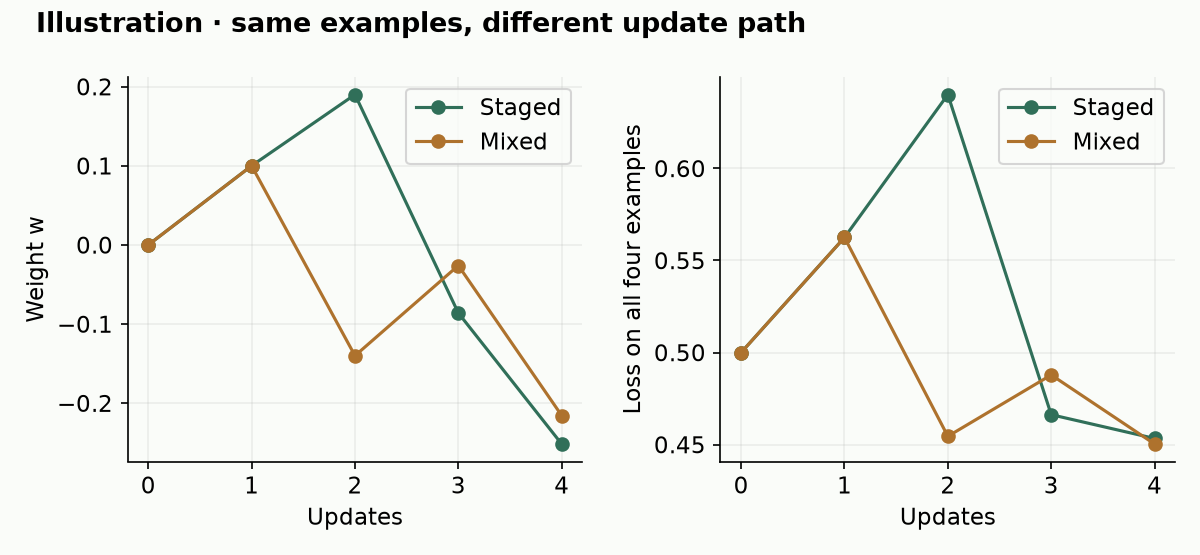<figcaption>Four-example SGD trace; illustrative training loss, not PFN evaluation. On narrow screens, scroll horizontally.</figcaption></figure>

The example demonstrates path dependence, not a rule that easy-first wins. At intermediate steps the two schedules have seen different subsets. Only at the end have both seen the same multiset: the same examples with the same repetition counts.

**CHECK.** If one stage restarts Adam's moving averages while the shuffled run keeps them, have we changed only order? No: optimizer state is another intervention.

## 3 · Model architecture: where does the order enter?

The paper uses PluRel to generate tables and databases, then the RDB-PFN consumer to learn across tasks. The diagram distinguishes that design from the compact course implementation. The paper describes six layers and width128; our inherited released-base mirror defaults to width96. That discrepancy is part of the historical source gate, not something to hide by choosing whichever trains fastest. [Paper §2–3](https://arxiv.org/html/2607.29120v1#S3)

<figure class="curriculum-figure" tabindex="0" role="region" aria-label="Source-shaped compact course PFN; query labels never enter the predictor." style="max-width:100%;overflow-x:auto">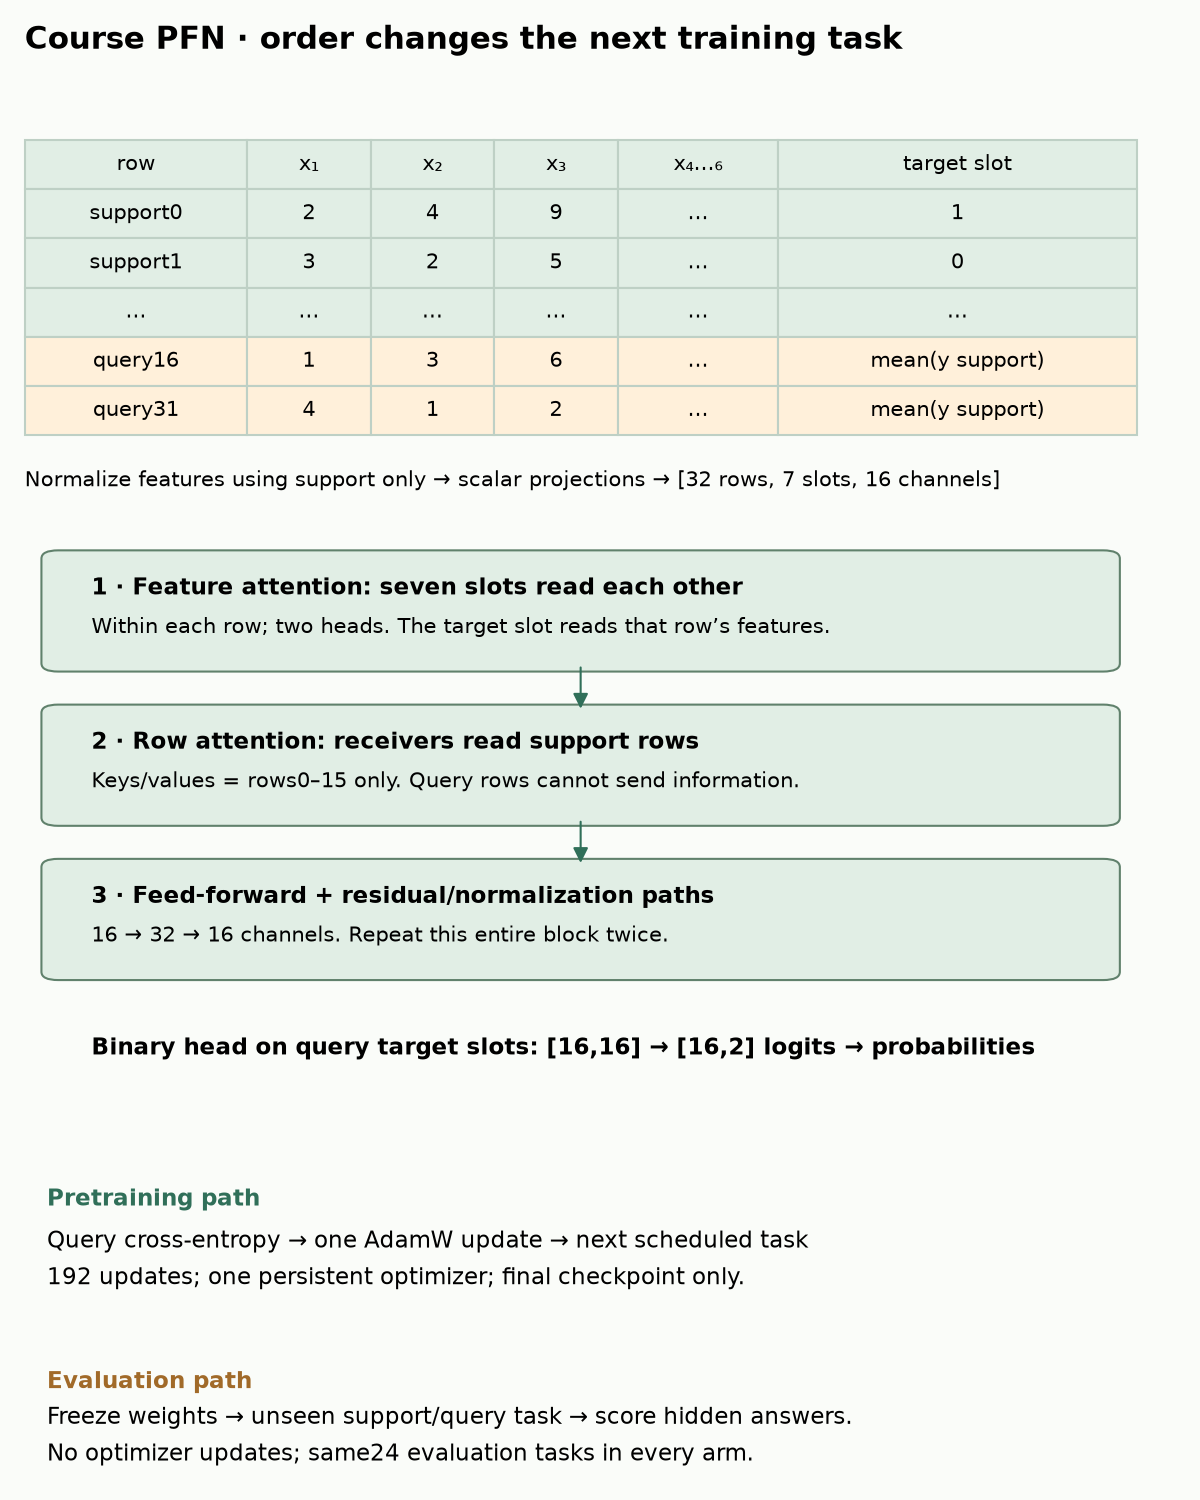<figcaption>Source-shaped compact course PFN; query labels never enter the predictor. On narrow screens, scroll horizontally.</figcaption></figure>

**Input.** One course task has32 rows and6 feature slots. The first16 rows are support; their binary labels are available. The last16 are queries. Each feature is centered and scaled using support rows only. Scalar values become vectors of length16. A seventh slot stores the target embedding: the observed support label or the support-label mean as a query placeholder.

**Feature attention.** Within each row, attention mixes its seven slots. An attention weight measures how strongly one vector reads another for this computation; it is not a causal feature attribution.

**Row attention.** For each feature slot, every receiver may read the16 support rows. Queries are never keys or values, so one query cannot convey its unknown target or alter another query through that route. Two repeated blocks apply feature attention, row attention, normalization and a small feed-forward network. A binary head maps each query's target slot to two logits; softmax converts them to class probabilities.

**Training versus prediction.** The model predicts16 query labels. Cross-entropy compares those probabilities with the hidden training answers, then AdamW updates weights. The scheduler selects the next task. Evaluation freezes weights and presents new tasks. A loss function can read answers after prediction without those answers being predictor inputs.

> **Scope check.** The notebook exposes the complete compact model and trainer. Its two blocks, width16, tiny course priors and192 updates differ from the paper. Output and gradient agreement with the inherited B13 implementation checks this mechanism, not the authors' unrecovered experiment code.

## 4 · Freeze the comparison before inspecting the scores

Our declared grid has two generators × two orders × three paired seeds = **12 fits**. Each training pool contains96 tasks at active widths2,4,6. Every task has32 rows and is used twice. The staged arm shuffles within each width bucket and visits buckets narrow-to-wide. The shuffled arm mixes all192 task exposures. Both use the same padded6-column shape and the final checkpoint after192 updates.

Within each ordering pair, task bytes, initial weights, AdamW settings, exposure counts and evaluation tasks are identical. Optimizer state continues across every stage. There is no early stopping or hyperparameter search. We save every schedule and prediction. Changing generator family is a separate intervention: it changes the data, so that contrast cannot be called a pure ordering effect.

**The course relational prior.** It generates32 parent rows and96 child rows with valid foreign keys, then forms parent features and count/mean/max aggregates. Narrow stages retain fewer of those features; they still generate the full underlying database. This tests feature-exposure order, not progressively larger relational schemas. The single-table prior uses independent Gaussian features. Both construct per-task random linear targets with noise; the binary threshold uses support rows only.

| Quantity | Why count it? | Frozen course value |
|---|---|---|
| Unique synthetic tasks | Data diversity | 96 per pool |
| Task exposures | Reuse can hide extra training | 192 per fit |
| Optimizer updates | Count optimization steps | 192 per fit, batch1 |
| Model feature cells processed | Width/rows change work per exposure | 36,864 per fit, padding included |
| Generated raw cells | Cost before model input | Separate family conventions in contract |
| Wall-clock seconds | Measures actual execution | Recorded per fit; not inferred from database count |

The same model-cell count is a useful control here because tensor dimensions are fixed. It is not a universal measure of compute: attention, memory, preprocessing and hardware also matter. Reusing a database twice does not create another independent database.



| Prior | Order | AUROC: seed0 /1 /2 | Mean AUROC | Mean cross-entropy ↓ |
|---|---|---|---:|---:|
| single | staged | 0.4322 / 0.4351 / 0.4232 | 0.4302 | 0.6947 |
| single | shuffled | 0.4314 / 0.5474 / 0.4195 | 0.4661 | 0.6945 |
| relational | staged | 0.4460 / 0.4604 / 0.4989 | 0.4684 | 0.6926 |
| relational | shuffled | 0.4359 / 0.5625 / 0.5738 | 0.5241 | 0.6918 |


<figure class="curriculum-figure" tabindex="0" role="region" aria-label="All12 fits and three paired seeds; fixed synthetic evaluation pool." style="max-width:100%;overflow-x:auto">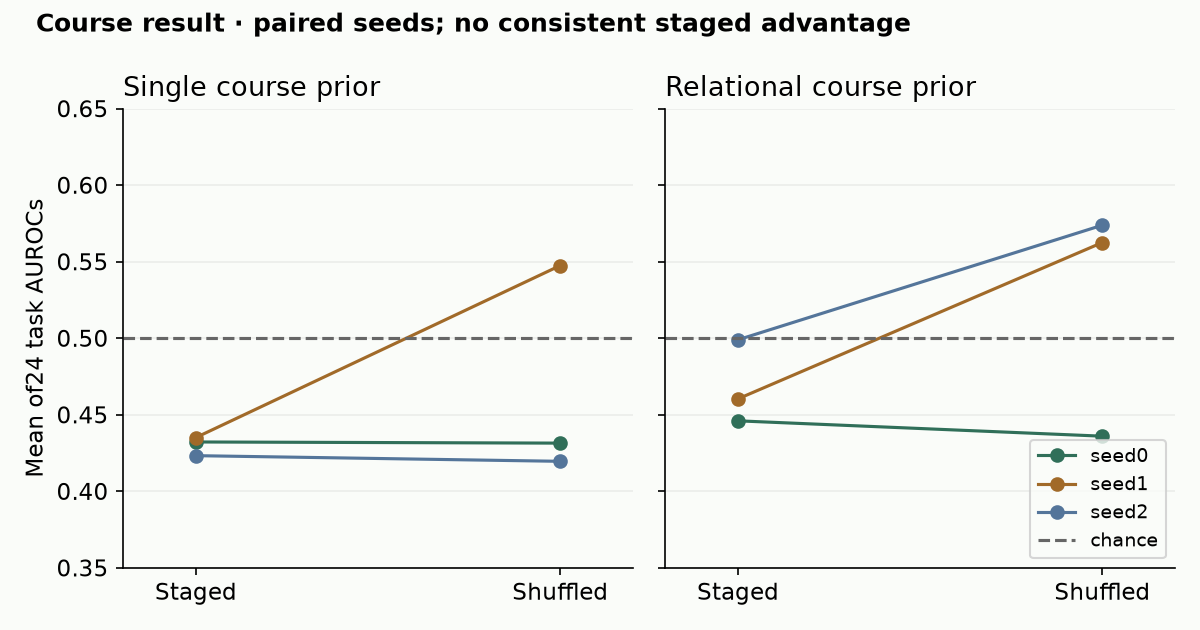<figcaption>All12 fits and three paired seeds; fixed synthetic evaluation pool. On narrow screens, scroll horizontally.</figcaption></figure>

Evaluation uses the same24 unseen synthetic tasks for all fits:12 from each family,16 query rows per task. **AUROC** is the fraction of positive-negative pairs ranked correctly, with half-credit for ties. We compute it per task and average tasks equally. Binary cross-entropy also checks probability quality; a constant0.5 prediction has loss about0.6931.

The models are weak at this budget. Most AUROCs are around or below chance, and their probability losses are near that constant baseline. The paired ordering differences change by seed; these results do not establish a beneficial curriculum or relational-pretraining advantage. Seed variation measures this training procedure's variability on one fixed synthetic evaluation pool, not uncertainty over all real databases. We retain the full grid rather than select the most favorable seed.

**CHECK.** Make one test label change. The saved trained weights must stay fixed. The reported score should change. If training changes, evaluation has leaked into model construction.

## 5 · Reconstruct the named paper comparison

Primary reading: [Curriculum Matters v1, Table1 and Tables5–6](https://arxiv.org/html/2607.29120v1#S4.T1). Read §3 first to identify Family A's progressive single-table stages and Family B's mixed version of the same corpus. The reported comparison uses23 tasks and context1024. It is our declared historical target.

| Printed row | Mean of23 listed scores | Displayed average | Matches at3 decimals? |
|---|---:|---:|---|
| TF07 | 0.567217 | 0.567 | Yes |
| TF08 | 0.603609 | 0.604 | Yes |
| TF09 | 0.625957 | 0.626 | Yes |
| TF10 | 0.653783 | 0.654 | Yes |
| TF12 | 0.714957 | 0.715 | Yes |
| TF13 | 0.696565 | 0.697 | Yes |
| TF14 | 0.705130 | 0.705 | Yes |
| TF15 | 0.694478 | 0.694 | Yes |
| TF16 | 0.687087 | 0.687 | Yes |
| TF17 | 0.702652 | 0.703 | Yes |
| Best ours | 0.729652 | 0.715 | No |
| Family B all-at-once | 0.540783 | 0.541 | Yes |
| Paper (single-tbl) | 0.799870 | 0.800 | Yes |
| Paper (full) | 0.809913 | 0.810 | Yes |


We parsed all14 rows ×23 task scores = **322 printed scores**, including every listed stage and both published baselines. The final Family A mean is0.702652 and B is0.540783; their gap is0.161870. These round to the headline0.703 and0.541. This is a complete audit of that printed matrix, not newly generated predictions.

**A summary mismatch.** The “Best ours” task entries average to0.729652, whereas its average column says0.715. The latter matches the best single listed checkpoint, TF12. Per-task maxima and one selected checkpoint answer different questions; a collection of best test scores is not a deployable checkpoint-selection procedure.

**A prose mismatch.** The paper says all-at-once degrades on every task. The printed final A/B comparison instead favors A on21 tasks and B on two: Diabetes130US and pol. Retain both exceptions. AppendixB's four-decimal exactness claims also require care because the input scores are already rounded.

**Historical identity still matters.** The paper's stage table omits TF11 despite the TF07–TF17 wording. Exact corpus bytes, exposures, architecture, optimizer schedule, seeds, splits, checkpoint selection and support identities remain unresolved. FamilyG has two descriptions. C-versus-E changes initialization as well as relational ordering. These ambiguities restrict causal interpretation and prevent an exact training recipe from being invented. [Source packet](https://avistian.github.io/relational/labs/sources/b20/manifest.json) · [Audit report](https://avistian.github.io/relational/labs/evidence/b20/reproduction.json)

> **Reproduction status.** Printed-table audit COMPLETE. Historical training `INCOMPLETE_SOURCE_PROTOCOL_GATE`; fresh paper pretraining and whole-paper reproduction `NOT_RUN`. The tested reproduction command authenticates sources and audits tables. Its `--fresh` option refuses execution with the missing requirements. It does not pretend to be a complete historical trainer.

## 6 · “88% of performance” needs a denominator

**Worked example.** The paper compares relational AUROC0.638 with0.725. Dividing gives88%. But chance AUROC is0.5. The achieved margin is0.138 and the reference margin is0.225. Their ratio is about61.3%, not88%. Both calculations are valid; they describe different quantities. Neither is a percentage of errors avoided.

<figure class="curriculum-figure" tabindex="0" role="region" aria-label="Raw AUROC retention88% versus above-chance retention61.3%." style="max-width:100%;overflow-x:auto">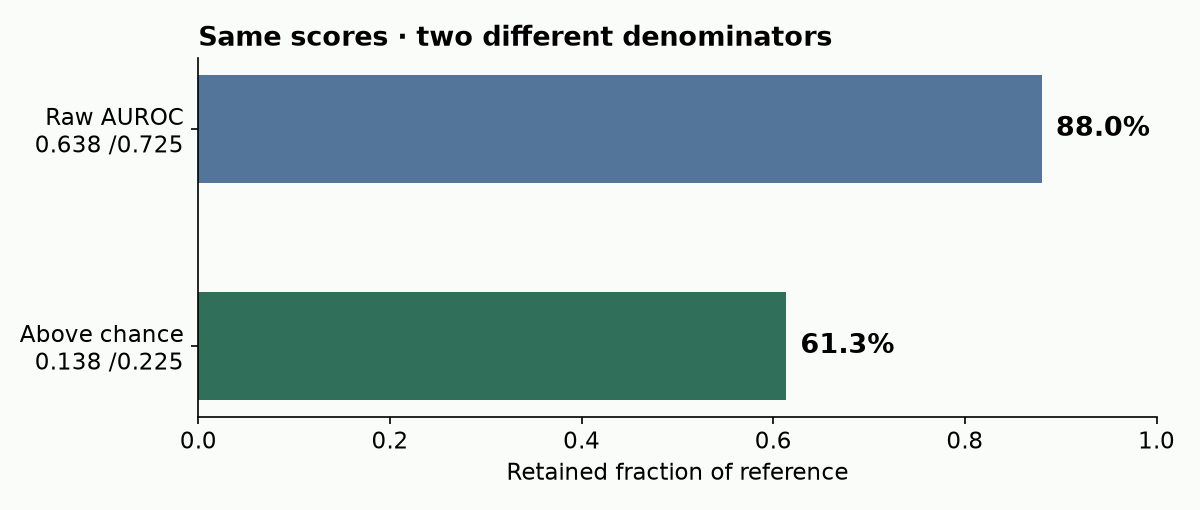<figcaption>Raw AUROC retention88% versus above-chance retention61.3%. On narrow screens, scroll horizontally.</figcaption></figure>

A count of databases also needs a unit. One database can yield multiple target tasks, contain many more cells, or be replayed for more updates. A smaller generated corpus alone does not establish a proportional compute saving. Compare data generation, optimization and inference costs separately.

## 7 · Build, falsify, explain

In the notebook, implement three live functions: an exposure schedule that preserves the task multiset, a paired-contract check that rejects changed controls, and raw/above-chance AUROC retention. Each has immediate checks. The notebook shows the model, generator and trainer inline; saved-evidence replay runs without a repository checkout. Fresh course training is an explicit optional rerun of the complete12-fit grid.

**Exit ticket.** Write a curriculum experiment for your L201 proposal. Name the prior, fixed task pool, stage variable, matched exposure count, optimizer-state policy and checkpoint-selection rule. State which cost is matched and which is only measured. Decide whether this elective belongs in your relational research direction.

Two falsification tests: (1) randomize order while keeping identical contents and exposures; does the advantage survive across paired seeds? (2) keep ordering fixed but match the proposed compute measure; does the smaller corpus still save the claimed resource? Explain why our small unsuccessful pretraining experiment cannot refute the full paper.



Revisit the contract from memory after1,7 and30 days. Ask the agent about any unclear step or paste your experiment and defense for feedback. Author preparation does not establish your mastery: **PENDING_WRITTEN_DEFENSE**.

[Back to B19b](https://avistian.github.io/relational/lessons/b19b-forecasting-contracts.html) · [Next planned elective: B21](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b21) · [Reproduction handoff: B23](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b23)


<!-- course-portable:start -->
### Follow the computation

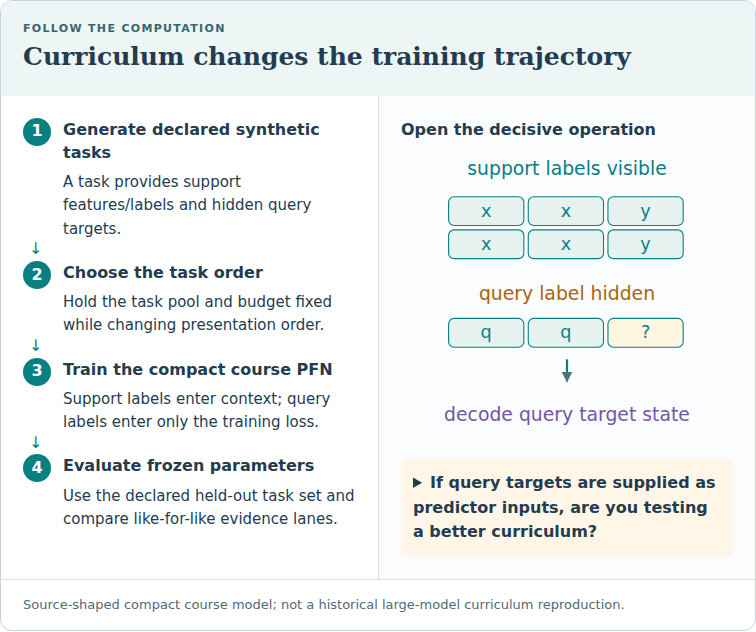

Source-shaped compact course model; not a historical large-model curriculum reproduction.

**Trace question:** If query targets are supplied as predictor inputs, are you testing a better curriculum?

**Trace answer:** No. You have changed information access and leaked answers. Task order cannot repair that contract violation.
<!-- course-portable:end -->

## PROVIDED · environment and portable packet
Run PROVIDED cells, implement TODOs, then run each CHECK. This notebook uses NumPy and PyTorch for the visible model. The default lane replays saved evidence, with no network or model downloads. Optional fresh course training comes after EXIT. Live Colab has not been tested.

In [ ]:
# @colab-bootstrap: standalone notebook; no repository checkout required.
import importlib.util, subprocess, sys
missing=[n for n in ['numpy','torch'] if importlib.util.find_spec(n) is None]
if missing: subprocess.check_call([sys.executable,'-m','pip','install',*missing])
import hashlib, io, json, zipfile
from pathlib import Path
from decimal import Decimal
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
torch.set_num_threads(1)


In [ ]:
import base64
packet=base64.b64decode('...')
assert hashlib.sha256(packet).hexdigest()=='c48ffb9ff6b739d0e3cd8ee109c473726e6759c74a02d742983e11cbefacfeac'
root=Path('b20-packet');root.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(packet)) as z:
    assert all(not Path(n).is_absolute() and '..' not in Path(n).parts for n in z.namelist())
    z.extractall(root)
manifest={'evidence/b20/reproduction.json': '92ca4c26560805e74b69753443fb6d74f3c2d7ea5054dd01abab92204d4cb00c', 'evidence/b20/predictions-relational-staged-2.npz': 'f287b932d6e7d227ae08a83617566ec9f22b764fb16c9de1e1552bf444733029', 'evidence/b20/pool-single-1.npz': '68c2caf2f43171d054c6e803ccc5979308a97fbeac925184c517fc06038f2453', 'evidence/b20/evaluation.npz': '387a72e7688b20852894181d0ff9c4b0ee9ab9bb755d0d2aa11f1d847837ca80', 'evidence/b20/weights-single-staged-2.pt': '8799a5db3e3a700c09c557887c0246682d93c31e8b08d09350fc044c82b13f62', 'evidence/b20/predictions-single-staged-2.npz': '9e3ee0714b1f727be5ff2101a0576dfb26522c300200d801a59adc44b2c983c2', 'evidence/b20/weights-relational-staged-0.pt': '1f0d8a1b65c5f134930e048b7141f8ad7362783e34329574645aeff4ed1830fd', 'evidence/b20/predictions-relational-shuffled-0.npz': '712a2a3782b15ef19a20518489f123b8d223f2ec8fabd03f5bc6ee8548f95c59', 'evidence/b20/predictions-single-shuffled-2.npz': '558ca6c185dde15c61290f80f3cc033eba1a5905ba4bff46e1527ae2008d1e2f', 'evidence/b20/pool-relational-1.npz': '48a2eccbcc660f9898e225cfe3223097341a3b251753de699867f2fb75382277', 'evidence/b20/predictions-single-shuffled-1.npz': '5d3d1df02d3295ab51ce9cf800d45ff39aefd3d78dfe046ad9c1b2836168f104', 'evidence/b20/pool-relational-2.npz': 'e33f01dbd3751b68bc465719b0a1edc09f0ba828c0c0572da402107a6c2396d4', 'evidence/b20/pool-single-2.npz': '1a305135580d0da951d52cc360cc4c88a8185601c70b549473f2a2ed0b5cf069', 'evidence/b20/predictions-single-staged-1.npz': '1a8534c68254f771d5ae2401a378d012f8dda04525572cd76af12efcc547ae44', 'evidence/b20/predictions-relational-shuffled-2.npz': '97a95dbdb4fe0e3128988bf387b5aa6d0d889d15540429de28546615828acaf5', 'evidence/b20/weights-relational-staged-1.pt': 'ee708a887ef18d7039bc3dd11619056be6a4ff3ee72b34de5f48803310db7008', 'evidence/b20/weights-single-shuffled-1.pt': '8e7f76c7b87014ff3eaa897c1d7636a51ed5eb4bad357f05cf99b25e7b3dd0f8', 'evidence/b20/weights-single-shuffled-2.pt': 'b5ea541a565ebfd8ec5b85754ebfea045eb7a3dcf9cd90bcd2d5f4ed644f62fa', 'evidence/b20/weights-single-shuffled-0.pt': '92c72dfa821505af9244bc866b90a57c1a24ce90744c02c66f11d197cde0c800', 'evidence/b20/weights-single-staged-1.pt': '5010492c4e8b41f1dc9145712cbb7ab7023ed7f3aa0c34079db8b500a2ed1bce', 'evidence/b20/predictions-single-shuffled-0.npz': 'ae15f3b671a250e7d78f7190daba15f711bdc4db7b9338bfa843c8dc6f1c26d9', 'evidence/b20/diagnostic.json': 'c6e23a5f71e974302e38255ad1b55a8098aff61f6062269242d5413725d6e1a3', 'evidence/b20/weights-single-staged-0.pt': '567f3a6cc73e9b460d57bb626d359d1e1952d2622db80a887ed20a39de833c99', 'evidence/b20/pool-single-0.npz': 'd30a7e5b2c8236c5f0f624556d5527fcd057d7584b7fd6701f2dceab2d2b0452', 'evidence/b20/paper-packet.json': '888922a46b6db893ae0761487d45191ff20dcd789b151255698cf1e85d494846', 'evidence/b20/predictions-single-staged-0.npz': '5ef5766cecf66480477e7a35bd0cb9643ed2e9d4d8374cb731608129aae8a896', 'evidence/b20/weights-relational-shuffled-1.pt': '08914c4255f45e69c319e5ea880961d4f47968d99128a8877972daa47a016770', 'evidence/b20/weights-relational-shuffled-2.pt': '731abf8663fb1e762b5082fbb83056f8af9173257a5ba4bf9fa559bc08006b1e', 'evidence/b20/predictions-relational-staged-0.npz': 'd9fd953fe73ca34b2b2db1f09e17088b30fd9dfdf83ab333e0efc16077d014b2', 'evidence/b20/weights-relational-staged-2.pt': '61fcf3a839f617b5918d846d99e21b7227356eebbd02632f66497c10b075089b', 'evidence/b20/weights-relational-shuffled-0.pt': '0d85d36fd74b3a0e62417af31e06e73b47a91ead71d842fcd5ab820d3707a517', 'evidence/b20/predictions-relational-staged-1.npz': '384b1605f060076751d618e28210219c1af6098b8e5442b098aa97abc7889d0f', 'evidence/b20/pool-relational-0.npz': '95d852bfc2a2c50763fd66b754908d2667905f6cd2f2858861fbaad5127bddf1', 'evidence/b20/predictions-relational-shuffled-1.npz': 'ec40c71687ca7d16eacf19f1b309a2dca742ef4da4225d8a1e9eed4336acad92', 'sources/b20/environment.json': 'bf07de21a241bc541e7abb7bf92a62dcab4d54342150e6ca7159982db3380be4', 'sources/b20/rdbpfn_visible.py': '01c9ded86741c253d6cf5cf48aa68d4931e416ed2060d384e267734a6ed8a8d7', 'sources/b20/rdbpfn-inherited-ledger.json': '1866f66b6e0314173e38dffb8884c3c3cc151fad13746dda13471e0b02ce3e6f', 'sources/b20/manifest.json': '549f1741e4d01f0e2282eb6b93924e40252f3759a94a86e23754a3f1f343e0df', 'sources/b20/paper.html': 'e9b6c83190381bfd42132d5861013d955cff0de4da8c41e7350b239af738ff3a'}
for name,digest in manifest.items():
    assert hashlib.sha256((root/name).read_bytes()).hexdigest()==digest,name
E=root/'evidence/b20'
print('Authenticated',len(manifest),'source/evidence files')

## TODO1 · preserve the exposure multiset
Implement the named contract from the lesson. Predict which error would invalidate the comparison before writing code. Preserve the supplied signature; invalid inputs should raise ValueError.

In [ ]:
def exposure_order(levels, mode, seed, repeats=2):
    raise NotImplementedError("Implement exposure_order")

In [ ]:
levels=np.array([2,0,1,0,2,1])
a=exposure_order(levels,'staged',7,2);b=exposure_order(levels,'shuffled',7,2)
assert len(a)==len(b)==12
assert np.all(np.diff(levels[a])>=0)
for order in [a,b]:np.testing.assert_array_equal(np.bincount(order,minlength=6),np.full(6,2))
np.testing.assert_array_equal(b,exposure_order(levels,'shuffled',7,2))
assert not np.array_equal(a,b)
print('CHECK: complete multiset, deterministic schedule, distinct order')

## TODO2 · reject a confounded pair
Implement the named contract from the lesson. Predict which error would invalidate the comparison before writing code. Preserve the supplied signature; invalid inputs should raise ValueError.

In [ ]:
def paired_contract(left, right):
    raise NotImplementedError("Implement paired_contract")

In [ ]:
left=dict(pool='p',init='i',updates=12,optimizer={'lr':.001},exposures=[2,2,2],selection='final',evaluation='e',batch_size=1)
assert paired_contract(left,dict(left))
for key in left:
    right=dict(left);right[key]='changed'
    try:paired_contract(left,right)
    except ValueError:pass
    else:raise AssertionError('Accepted changed '+key)
print('CHECK: every changed control rejected')

## TODO3 · make the denominator explicit
Implement the named contract from the lesson. Predict which error would invalidate the comparison before writing code. Preserve the supplied signature; invalid inputs should raise ValueError.

In [ ]:
def auc_retention(score, baseline):
    raise NotImplementedError("Implement auc_retention")

In [ ]:
r=auc_retention(.638,.725)
assert abs(r['raw']-.88)<1e-12
assert abs(r['above_chance']-.138/.225)<1e-12
try:auc_retention(.7,.5)
except ValueError:pass
else:raise AssertionError('Chance baseline accepted')
print('CHECK:',r)

## PROVIDED · course priors and identities
Trace this code against the architecture above. The course generator and model sizes are declared deviations from the paper.

In [ ]:
def task_pool(seed, family, count=96):
    if family not in ('single','relational') or count%3:raise ValueError('Family and balanced three-stage count required')
    rng=np.random.default_rng(seed);xs=[];ys=[];cells=[]
    widths=np.repeat([2,4,6],count//3)
    for width in widths:
        parent=rng.normal(size=(32,3))
        if family=='single':
            x=rng.normal(size=(32,6));generated=32*int(width)
        else:
            # PKs 0..31; 96 child FKs. Aggregate only feature values, never targets.
            fk=rng.integers(0,32,96);values=parent[fk,0]+rng.normal(size=96)
            counts=np.bincount(fk,minlength=32);sums=np.bincount(fk,weights=values,minlength=32)
            means=sums/np.maximum(counts,1);maxima=np.zeros(32)
            for row in range(32):
                if counts[row]:maxima[row]=values[fk==row].max()
            x=np.column_stack([parent,counts,means,maxima]);generated=32*4+96*2 # count physical PK/FK too
        x[:,width:]=0
        weights=rng.normal(size=6);weights[width:]=0
        score=x@weights/np.sqrt(width)+rng.normal(scale=.15,size=32)
        # Threshold from support only. Query targets cannot determine the task boundary.
        y=(score>np.median(score[:16])).astype(np.int64)
        xs.append(x.astype(np.float32));ys.append(y);cells.append(generated)
    return dict(x=np.stack(xs),y=np.stack(ys),levels=widths,cells=np.asarray(cells))

def array_hash(*arrays):
    h=hashlib.sha256()
    for a in arrays:
        a=np.ascontiguousarray(a);h.update(str((a.shape,str(a.dtype))).encode());h.update(a.tobytes())
    return h.hexdigest()

## PROVIDED · normalize and embed support/query inputs
Trace this code against the architecture above. The course generator and model sizes are declared deviations from the paper.

In [ ]:
def normalize_support(x, support):
    z=x.unsqueeze(-1);train=z[:,:support];valid=~torch.isnan(train)
    count=valid.sum(1,keepdim=True).clamp(min=1)
    mean=torch.where(valid,train,0.).sum(1,keepdim=True)/count
    var=torch.where(valid,train-mean,0.).square().sum(1,keepdim=True)/count
    return ((torch.where(torch.isnan(z),mean,z)-mean)/torch.sqrt(var+1e-20)).clamp(-100,100)

class FeatureEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,x,support):return self.linear_layer(normalize_support(x,support))

class TargetEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,y,rows):
        padding=y.float().mean(1,keepdim=True).repeat(1,rows-y.shape[1],1)
        return self.linear_layer(torch.cat([y,padding],1).unsqueeze(-1))

## PROVIDED · attention blocks and prediction head
Trace this code against the architecture above. The course generator and model sizes are declared deviations from the paper.

In [ ]:
class BiAttention(nn.Module):
    def __init__(self,width,heads,hidden):
        super().__init__()
        self.self_attention_between_features=nn.MultiheadAttention(width,heads,batch_first=True)
        self.self_attention_between_datapoints=nn.MultiheadAttention(width,heads,batch_first=True)
        self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width);self.norm3=nn.LayerNorm(width)
    def forward(self,x,support):
        b,n,f,d=x.shape
        z=x.reshape(b*n,f,d)
        z=self.norm1((z+self.self_attention_between_features(z,z,z)[0]).reshape(b,n,f,d))
        z=z.transpose(1,2).reshape(b*f,n,d);keys=z[:,:support]
        left=self.self_attention_between_datapoints(keys,keys,keys)[0]
        right=self.self_attention_between_datapoints(z[:,support:],keys,keys)[0]
        z=self.norm2((z+torch.cat([left,right],1)).reshape(b,f,n,d).transpose(1,2))
        return self.norm3(z+self.linear2(F.gelu(self.linear1(z))))

class Decoder(nn.Module):
    def __init__(self,width,hidden):
        super().__init__();self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,2)
    def forward(self,x):return self.linear2(F.gelu(self.linear1(x)))

class RDBPFN(nn.Module):
    """Compact course setting, not the paper's reported width/layers/checkpoint."""
    def __init__(self,width=16,heads=2,hidden=32,layers=2):
        super().__init__();self.feature_encoder=FeatureEncoder(width);self.target_encoder=TargetEncoder(width)
        self.transformer_blocks=nn.ModuleList([BiAttention(width,heads,hidden) for _ in range(layers)])
        self.decoder=Decoder(width,hidden)
    def forward(self,src,support):
        x,y=src
        if y.shape[1]!=support:raise ValueError('Pass support labels only')
        if y.ndim==2:y=y.unsqueeze(-1)
        z=torch.cat([self.feature_encoder(x,support),self.target_encoder(y,x.shape[1])],2)
        for block in self.transformer_blocks:z=block(z,support)
        return self.decoder(z[:,support:,-1])

## PROVIDED · persistent optimizer and final-checkpoint evaluation
Trace this code against the architecture above. The course generator and model sizes are declared deviations from the paper.

In [ ]:
def fit_course(pool, mode, seed):
    torch.set_num_threads(1);torch.manual_seed(seed)
    model=RDBPFN();initial=array_hash(*[v.detach().numpy() for v in model.state_dict().values()])
    order=exposure_order(pool['levels'],mode,100+seed,2)
    optimizer=torch.optim.AdamW(model.parameters(),lr=.001,weight_decay=.01)
    x=torch.from_numpy(pool['x']);y=torch.from_numpy(pool['y']);losses=[]
    for index in order:
        optimizer.zero_grad();logits=model((x[index:index+1],y[index:index+1,:16]),16)
        loss=F.cross_entropy(logits.reshape(-1,2),y[index,16:]);loss.backward();optimizer.step()
        losses.append(float(loss.detach()))
    return model,dict(init=initial,order=order.tolist(),losses=losses,optimizer_steps=int(next(iter(optimizer.state.values()))['step']))

def evaluate(model,pool):
    model.eval()
    with torch.no_grad():
        return model((torch.from_numpy(pool['x']),torch.from_numpy(pool['y'][:,:16])),16).softmax(-1)[...,1].numpy()

## CHECK · rescore all4608 predictions independently
The original run used sklearn AUROC. This audit counts every positive-negative pair directly, authenticates inputs and reconstructs predictions with the saved compact model weights. No new training is performed.

In [ ]:
import itertools
def audit(root,report):
    rows=report['rows'];expected=set(itertools.product(['single','relational'],['staged','shuffled'],[0,1,2]))
    assert len(rows)==12 and {(r['family'],r['mode'],r['seed']) for r in rows}==expected,'Incomplete grid'
    ev=np.load(root/'evaluation.npz');assert ev['x'].shape==(24,32,6)
    result=[]
    for row in rows:
        pool=np.load(root/f"pool-{row['family']}-{row['seed']}.npz")
        assert array_hash(pool['x'],pool['y'])==row['pool'],'Pool hash'
        assert array_hash(ev['x'],ev['y'])==row['evaluation'],'Evaluation hash'
        order=np.array(row['order']);assert len(order)==192 and np.all((order>=0)&(order<96))
        np.testing.assert_array_equal(np.bincount(order,minlength=96),np.full(96,2))
        assert row['exposures']==np.bincount(order,minlength=96).tolist()
        if row['mode']=='staged':assert np.all(np.diff(pool['levels'][order])>=0)
        assert row['optimizer_steps']==192 and len(row['losses'])==192
        assert row['generated_cells']==int(pool['cells'].sum())
        pred=np.load(root/f"predictions-{row['name']}.npz");p=pred['p'];y=pred['y']
        np.testing.assert_array_equal(y,ev['y'][:,16:]);assert p.shape==y.shape==(24,16)
        assert np.isfinite(p).all() and np.all((p>0)&(p<1))
        auc=[]
        for a,b in zip(y,p):
            pos=b[a==1];neg=b[a==0];assert len(pos) and len(neg)
            auc.append(float(((pos[:,None]>neg).sum()+.5*(pos[:,None]==neg).sum())/(len(pos)*len(neg))))
        score=float(np.mean(auc));loss=float(-(y*np.log(p.astype(float))+(1-y)*np.log1p(-p.astype(float))).mean())
        assert abs(score-row['auc'])<1e-12 and abs(loss-row['logloss'])<1e-7,'Metric mismatch'
        weights=torch.load(root/f"weights-{row['name']}.pt",weights_only=True)
        assert array_hash(*[v.numpy() for v in weights.values()])==row['final']
        model=RDBPFN();model.load_state_dict(weights);np.testing.assert_array_equal(evaluate(model,dict(ev)),p)
        result.append(dict(name=row['name'],auc=score,logloss=loss))
    for family,seed in itertools.product(['single','relational'],[0,1,2]):
        pair=[r for r in rows if r['family']==family and r['seed']==seed];paired_contract(*pair)
    return result

In [ ]:
report=json.loads((E/'diagnostic.json').read_text())
independent=audit(E,report)
Path('b20-replay.json').write_text(json.dumps(independent,indent=2)+'\n')
print('Full grid verified:',len(independent),'fits and4608 predictions')
for family in ['single','relational']:
    for seed in [0,1,2]:
        rows=[r for r in report['rows'] if r['family']==family and r['seed']==seed]
        paired_contract(*rows)
        print(family,seed,'staged-minus-shuffled AUROC',round(rows[0]['auc']-rows[1]['auc'],5))

## CHECK · reconstruct all322 printed scores
Read the archived primary HTML for provenance. The packet contains every task score from Tables5–6; the following Decimal calculation avoids binary rounding in the arithmetic audit.

In [ ]:
def replay(packet):
    out=[]
    for row in packet['rows']:
        mean=sum(Decimal(x) for x in row['scores'])/Decimal(23)
        reported=Decimal(row['reported'])
        # Each input and displayed average can differ by up to .0005 due to rounding.
        out.append(dict(label=row['label'],mean=float(mean),printed_average=float(reported),difference=float(mean-reported),matches_3_decimals=abs(mean-reported)<Decimal('.0005'),compatible_with_input_rounding=abs(mean-reported)<=Decimal('.001')))
    by={x['label']:x for x in out};a=by['TF17'];b=by['Family B all-at-once']
    av=next(x for x in packet['rows'] if x['label']=='TF17')['scores'];bv=next(x for x in packet['rows'] if x['label']=='Family B all-at-once')['scores']
    table1=[]
    for label,count,printed in packet['table1'][1:]:
        if 'All-at-once' in label:key='Family B all-at-once'
        elif 'RDB-PFN' in label:key='Paper (single-tbl)'
        else:key=label.split()[-1]
        table1.append(dict(label=label,printed=printed,reconstructed=by[key]['mean'],matches_3_decimals=abs(Decimal(str(by[key]['mean']))-Decimal(printed))<Decimal('.0005')))
    appendix_targets={'TF12':'0.7150','TF17':'0.7026','Family B all-at-once':'0.5407','Paper (single-tbl)':'0.7997'}
    appendix=[]
    for label,value in appendix_targets.items():
        assert value in packet['appendix_b']
        mean=Decimal(str(by[label]['mean']));diff=abs(mean-Decimal(value))
        appendix.append(dict(label=label,claimed_exact=value,reconstructed=float(mean),matches_4_decimals=diff<Decimal('.00005'),compatible_with_rounded_inputs=diff<=Decimal('.00055')))
    return dict(table1=table1,appendix_b=appendix,status='COMPLETE_PRINTED_TABLE_AUDIT',historical_reproduction='INCOMPLETE_SOURCE_PROTOCOL_GATE',fresh_training='NOT_RUN',tasks=23,configurations=len(out),score_cells=23*len(out),rows=out,selected=dict(a_mean=a['mean'],b_mean=b['mean'],gap=a['mean']-b['mean'],tasks_a_better=sum(Decimal(x)>Decimal(y) for x,y in zip(av,bv)),tasks_b_better=sum(Decimal(y)>Decimal(x) for x,y in zip(av,bv)),ties=sum(x==y for x,y in zip(av,bv))),claim='Printed-table arithmetic only; no raw predictions or historical weights')

In [ ]:
paper_packet=json.loads((E/'paper-packet.json').read_text())
paper_report=replay(paper_packet)
assert paper_report==json.loads((E/'reproduction.json').read_text())
Path('b20-paper-replay.json').write_text(json.dumps(paper_report,indent=2)+'\n')
print(paper_report['selected'])
for row in paper_report['rows']:
    if not row['matches_3_decimals']:print('SUMMARY MISMATCH:',row)
print('Printed arithmetic COMPLETE; historical training NOT_RUN')

## EXIT · make the causal claim defensible
Explain why the small failed training experiment cannot refute the paper. Distinguish per-task best scores from a validation-selected checkpoint. Submit a frozen order-versus-scale proposal with two falsification tests. Learner status remains PENDING_WRITTEN_DEFENSE until assessed.

## Optional fresh course run · complete12-fit grid
This executes the visible trainer on the frozen pools; it is not paper pretraining. The saved replay above is the default. Do not select a favorable subset of seeds. No paid resources are used. The author's PyTorch/NumPy versions are recorded in the packet; other versions may not give byte-identical floating-point results.

In [ ]:
RUN_FRESH_COURSE=False
if RUN_FRESH_COURSE:
    import time
    start=time.monotonic();fresh=[]
    for seed in [0,1,2]:
        for family in ['single','relational']:
            pool=dict(np.load(E/f'pool-{family}-{seed}.npz'))
            for mode in ['staged','shuffled']:
                if time.monotonic()-start>600:raise RuntimeError('INCOMPLETE_LOCAL_BUDGET_GATE')
                model,trace=fit_course(pool,mode,seed)
                probability=evaluate(model,dict(np.load(E/'evaluation.npz')))
                fresh.append(dict(seed=seed,family=family,mode=mode,p=probability.tolist(),init=trace['init']))
    Path('b20-fresh-course.json').write_text(json.dumps(fresh))
    print('Complete course rerun:',len(fresh),'fits; paper NOT_RUN')

## Paper-results operator · source gate
Full named target: Table1 A/B, all23 tasks at context1024. Exact historical corpus, schedule, architecture, seeds/splits, checkpoint selection and evaluation support identities remain unresolved. This notebook authenticates the archived source and reconstructs the printed matrix. It cannot manufacture the missing historical trainer. In the repository run `python labs/_reproduce_b20.py`; `--fresh` intentionally refuses execution. No fresh paper pretraining, raw paper prediction scoring or whole-paper reproduction has run.

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    raise RuntimeError('NOT_RUN: INCOMPLETE_SOURCE_PROTOCOL_GATE. Resolve the historical identities in b20-reproduction.md before training.')